<a href="https://colab.research.google.com/github/Ritesh-panda/Deep-learning/blob/main/CNN_practical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import tensorflow as tf #deeplearning framework
from tensorflow import keras#WRAPPERCLASS
from keras.datasets import fashion_mnist
from keras.layers import Dense, Flatten, Dropout
# Dropout :Regularization tech to overcome the overfitting problem
from keras.layers import Conv2D, MaxPooling2D
#conv1D:Audio
#conv2D:image
#conv3D:video

from keras import backend as K
from keras.models import Sequential #like in ml we use rf dt etc in dl we use sequential

In [26]:
num_classes=10#donot change unless datachanges

In [27]:
#defining the batch and epoch size
batch_size=64
epochs=24


In [28]:
img_rows,img_cols=28,28 #it means that the input img should be a size of 28,28

In [29]:
#suffle the data and fix it into training and testing data
(x_train,y_train), (x_test,y_test)=fashion_mnist.load_data()

In [30]:
#reshaping the data
x_train = x_train.reshape(x_train.shape[0],img_rows,img_cols,1)
x_test=x_test.reshape(x_test.shape[0],img_rows,img_cols,1)
input_shape=(img_rows,img_cols,1)

In [31]:
#type conversion and scale the testing and the training data
x_train= x_train.astype('float32')
x_test=x_test.astype('float32')
#feature scaling
x_train /=255 #value ranges from 0-255
x_test /=255
print('x_train shape:',x_train.shape)
print('x_test shape:',x_test.shape)


x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


In [32]:
#convert the vector into binary class metrices:one hot encoding
y_train=tf.keras.utils.to_categorical(y_train, num_classes)
y_test=tf.keras.utils.to_categorical(y_test, num_classes)

CNN MODEL STARTS HERE


In [33]:
model=Sequential()

In [34]:
model.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=input_shape))
#here there are 32 feature and the feature detector shape is having 3,3
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(32,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
#above is called as a 2 layer conv network
model.add(Flatten())
#covert the value from the matrix and 1 d
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(num_classes,activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,002 (472.66 KB)

 Trainable params: 121,002 (472.66 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(loss=keras.losses.categorical_crossentropy,#this crossentropy is for multi class classifier for loss calculation
              optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              metrics=['accuracy'])

hist=model.fit(x_train,y_train,
               batch_size=batch_size,
               epochs=epochs,
               verbose=1,
               validation_data=(x_test,y_test))

Epoch 1/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 59ms/step - accuracy: 0.5855 - loss: 1.2687 - val_accuracy: 0.7895 - val_loss: 0.5713
Epoch 2/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 53ms/step - accuracy: 0.8102 - loss: 0.5196 - val_accuracy: 0.8214 - val_loss: 0.4908
Epoch 3/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.8381 - loss: 0.4524 - val_accuracy: 0.8381 - val_loss: 0.4484
Epoch 4/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accuracy: 0.8542 - loss: 0.4139 - val_accuracy: 0.8496 - val_loss: 0.4287
Epoch 5/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 71s 56ms/step - accuracy: 0.8629 - loss: 0.3892 - val_accuracy: 0.8598 - val_loss: 0.3982
Epoch 6/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 75s 49ms/step - accuracy: 0.8687 - loss: 0.3726 - val_accuracy: 0.8607 - val_loss: 0.3949
Epoch 7/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 49ms/step - accuracy: 0.8727 - loss: 0.3601 - val_accuracy: 0.8648 - val_loss: 0.3817
Epoch 8/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.8781 - loss: 0.3468 - 

Test loss: 0.29487401247024536
Test accuracy: 0.8916000127792358


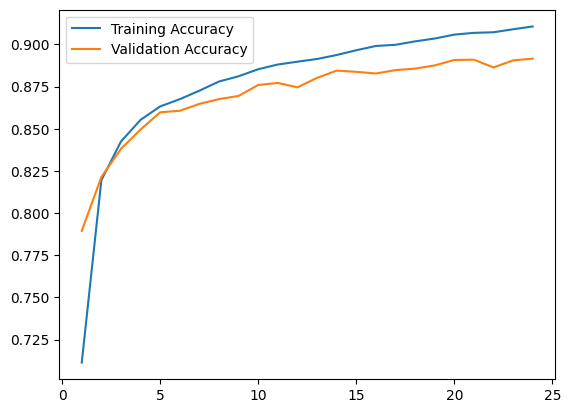

In [36]:
score=model.evaluate(x_test,y_test,verbose=0)
print('Test loss:',score[0])
print('Test accuracy:',score[1])
import numpy as np
import matplotlib.pyplot as plt
#plot the dataset to show the relation between the training and validation_Data
%matplotlib inline
epoch_list=list(range(1,len(hist.history['accuracy'])+1))
plt.plot(epoch_list,hist.history['accuracy'],epoch_list,hist.history['val_accuracy'])
plt.legend(('Training Accuracy','Validation Accuracy'))
plt.show()


In [37]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 363,008 (1.38 MB)

 Trainable params: 121,002 (472.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 242,006 (945.34 KB)